In [ ]:
!pip install wbdata

In [ ]:
import wbdata
import pandas as pd
import datetime
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
countries = ['IE', 'GB', 'DE']
indicator = 'NY.GDP.MKTP.CD'

In [ ]:
all_data = []

In [ ]:
for country in countries:
    url = f"http://api.worldbank.org/v2/country/{country}/indicator/{indicator}?format=json&per_page=100"
    response = requests.get(url)
    json_data = response.json()

In [ ]:
if isinstance(json_data, list) and len(json_data) > 1:
        for entry in json_data[1]:
            year = entry['date']
            value = entry['value']
            if value is not None:
                all_data.append({
                    'Country': country,
                    'Year': int(year),
                    'GDP_USD': value
                })


In [ ]:
df_api = pd.DataFrame(all_data)

In [ ]:
df_api = df_api.sort_values(by=["Country", "Year"])

df_api.head()

,Country,Year,GDP_USD
63,DE,1960,8.461985e+10
62,DE,1961,9.655820e+10
61,DE,1962,1.058954e+11
60,DE,1963,1.122325e+11
59,DE,1964,1.233304e+11


In [ ]:
df = pd.read_csv("/content/aa(1).csv")

In [ ]:
df = pd.melt(
    df,
    id_vars=["Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="CSV_Value_Added_USD"
)


In [ ]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["CSV_Value_Added_USD"] = pd.to_numeric(df["CSV_Value_Added_USD"], errors="coerce")

In [ ]:
df = df.dropna(subset=["Year", "CSV_Value_Added_USD"])

In [ ]:
countries_of_interest = ['IE', 'GB', 'DE']
df = df[df['Country Code'].isin(countries_of_interest)]

In [ ]:
df_api = df_api.reset_index()
# Convert the 'date' column to datetime if it's not already
df_api['Year'] = pd.to_datetime(df_api['Year'], format='%Y').dt.year # Assuming 'Year' contains only the year part
df_api.rename(columns={'Country': 'Country Name'}, inplace=True)

In [ ]:
df_csv = pd.read_csv("/content/aa(1).csv")
columns_to_keep = ['Country Name', 'Country Code'] + [str(y) for y in range(2015, 2023)]
df_csv_clean = df_csv[columns_to_keep]

In [ ]:
df_csv_long = df_csv_clean.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='CSV_Value_Added_USD'
)
df_csv_long['Year'] = df_csv_long['Year'].astype(int)

In [ ]:
df_api['Country Code'] = df_api['Country Name']

In [ ]:
merged_df = pd.merge(df_api, df, on=['Country Code', 'Year'], how='inner')

In [ ]:
df = df[[ 'Indicator Name','Indicator Code','Country Code', 'Year',  'CSV_Value_Added_USD']]

In [ ]:
df1 = pd.read_csv("/content/aa(1).csv")

In [ ]:
countries = ['Ireland', 'United Kingdom', 'Germany', 'France', 'United States']
df1_filtered = df1[df1['Country Name'].isin(countries)]

In [ ]:
df1_filtered = df1_filtered.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code'])

In [ ]:
df1_long = df1_filtered.melt(id_vars='Country Name', var_name='Year', value_name='Value Added (US$)')
df1_long['Year'] = pd.to_numeric(df1_long['Year'], errors='coerce')
df1_long = df1_long.dropna(subset=['Year', 'Value Added (US$)'])

In [ ]:
df1_norm = df1_long.copy()
# Calculate the base value for each country
base_values = df1_norm.groupby('Country Name')['Value Added (US$)'].transform('first')
# Calculate the Value Index
df1_norm['Value Index (Base = 100)'] = (df1_norm['Value Added (US$)'] / base_values) * 100

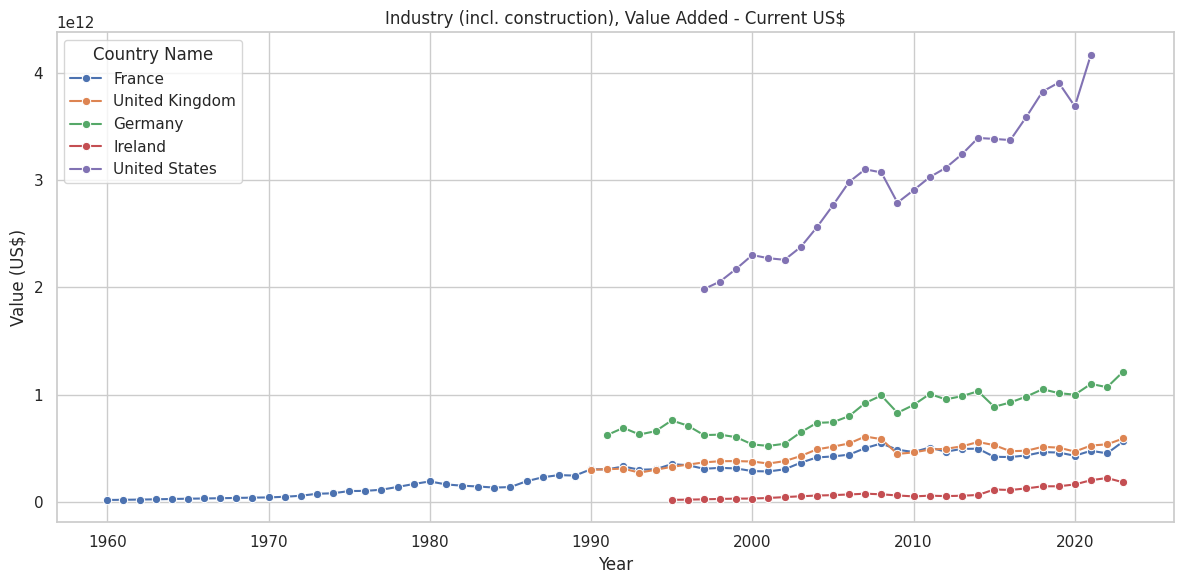

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df1_long, x='Year', y='Value Added (US$)', hue='Country Name', marker='o')
plt.title('Industry (incl. construction), Value Added - Current US$')
plt.ylabel('Value (US$)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()
